In this notebook we compute the ideal input current that would result in a perfect match between the recordings from the single-compartment neuron and the data.

It also contains plots about how much current runs through each channel.

In [1]:
import os
os.environ['XLA_FLAGS'] = '--xla_cpu_use_thunk_runtime=false'
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.95"

%load_ext autoreload
%autoreload 2


from jax import config
config.update("jax_enable_x64", True)



import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import numpy as np
import jaxley as jx


import equinox as eqx

import jax.random as jr
from typing import List

In [2]:
t_max = 250.0
cut = 1500

setup = "488683425"
# setup = "485574832"
# setup = "480353286"
# setup = "473601979"



# Define target
from voltage_fitting.build_simulator import (
    get_experimental_data,
)
t, v_data, i_amp = get_experimental_data(setup, cut, t_max)
v_data = jnp.asarray(v_data[None,])

dt_difference 5.0
Amplitude stimulus: 0.20999999344348907


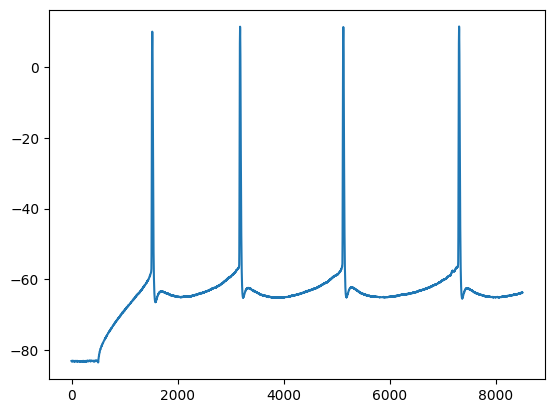

In [3]:
plt.plot(v_data[0])

In [4]:
#Define the cell
from voltage_fitting.single_build_simulator import (
    setup_simulator,
    setup_simulator_step,
    build_cell,
    set_setup,
    get_bounds,
    transform_uniform_to_normal,
    get_prior
)

from voltage_fitting.loss_util import (
    get_scaled_loss
)

seed = 0

rng_key = jax.random.PRNGKey(seed)

all_setup = set_setup(setup)
cell = build_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup["length"])
simulate_single = setup_simulator(cell, cut, t_max, all_setup["v_init"], i_amp)


# Sampling parameters
_, lower, upper = get_bounds()

transform_params, inv_transform_params = transform_uniform_to_normal(lower, upper)
sample_prior = get_prior(lower, upper, transform_params)

init_rng_key, sampling_rng_key = jax.random.split(rng_key)

# Sample 1 initialization randomly.
sampled_params = sample_prior(init_rng_key)
inv_sampled_params = inv_transform_params(sampled_params)

v_single = simulate_single(inv_sampled_params, v_data[0])[0]

Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.
Number of parameters: 15


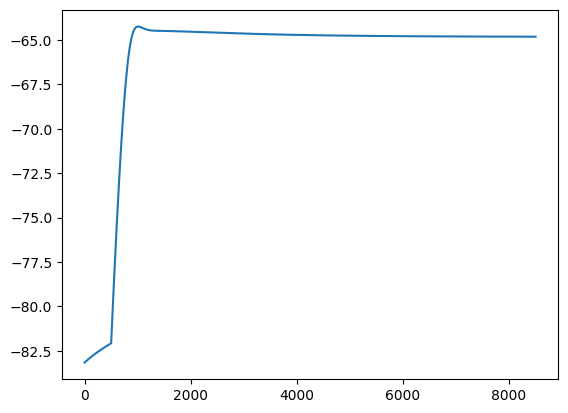

In [5]:
plt.plot(v_single[0])

**Initialization**

In [6]:
# Define the networks
@jax.jit
def normalize_voltage(v):
    # Normalize voltage between -1 and 1
    return 2 * (v - jnp.min(v_data)) / (jnp.max(v_data) - jnp.min(v_data)) - 1

@jax.jit
def softsign_transform(v):
    return v / (1 + jnp.abs(v))

@jax.jit
def tempered_tanh(v, scale=0.05):
    return jnp.tanh(scale * v)


In [7]:
class ParameterModel(eqx.Module):
    channel_params_normal: jax.Array

    def __init__(self, *, init_params):
        self.channel_params_normal = init_params

In [30]:
dt = 0.025
max_add_current = 1000.0
min_add_current = -1000.0
v_treshold = 0.5

def compute_surface_area(radius, length):
    area = 2 * jnp.pi * radius * length
    return area * 1e-8  # Convert to cm^2

def compute_ideal_add_by_root_search(state, x_next, step_fn, current_range=(-1.0, 1.0), tol=1e-4, max_iter=100):
    def objective(I_add):
        total_current = I_add
        _, rec = step_fn(state, total_current)
        v_next_pred = rec[0]
        return v_next_pred - x_next

    def binary_search(low, high, depth):
        mid = (low + high) / 2.0
        f_mid = objective(mid)
      
        too_low = f_mid < 0.0

        new_low = jnp.where(too_low, mid, low)
        new_high = jnp.where(too_low, high, mid)

        return (new_low, new_high, depth + 1)

    def cond_fun(val):
        low, high, depth = val
        return jnp.logical_and(depth < max_iter, jnp.abs(high - low) > tol)

    def body_fun(val):
        return binary_search(*val)

    low, high = current_range
    low, high, _ = eqx.internal.while_loop(cond_fun, body_fun, (low, high, 0), max_steps = max_iter, kind="bounded")
    return (low + high) / 2.0

def compute_ideal_add_analytic(v_target, state, step_fn, radius, length):
    cm = 1.0
    area = compute_surface_area(radius, length)

    zero_current = 0.0
    _, rec = step_fn(state, zero_current)

    dvdt = (v_target - rec[0]) / dt  # mV/ms
    return dvdt * area * cm * 1000  # Convert to nA

def simulate_full_trace(initial_state, step_fn, current, time_vec, x_o, thr = None):
    def cond_fn(carry):
        t, _, _, _, _, diff = carry
        keep_running = t < len(time_vec)
    
        if thr is None:
            return keep_running
        else:
            return jnp.logical_and(keep_running, diff < thr)

    def body_fn(carry):
        t, state, new_recs, ideal_adds, i_s, diff = carry
        ideal_add = compute_ideal_add_by_root_search(
                    state, x_o[t+1], step_fn, current_range=(min_add_current, max_add_current)
                )
        # ideal_add = compute_ideal_add_analytic(x_o[t+1], state, step_fn, 8.0, all_setup["length"])

        state, rec = step_fn(state, ideal_add)

        i_Na = state["i_Na"][0]
        i_K = state["i_K"][0]
        i_Leak = state["i_Leak"][0]
        i_Ca = state["i_Ca"][0]
        i_H = state["i_H"][0]


        rec_voltage = rec[0]

        i_s = i_s.at[t].set(jnp.asarray([i_Na, i_K, i_Leak, i_Ca, i_H]))
        new_recs = new_recs.at[t].set(rec_voltage)
        ideal_adds = ideal_adds.at[t].set(jnp.squeeze(ideal_add))

        new_diff = diff + (rec_voltage - x_o[t + 1])**2

        return (t + 1, state, new_recs, ideal_adds, i_s, new_diff)

    # Initialize buffers
    recs = jnp.full((len(time_vec),), jnp.nan)
    ideal_adds = jnp.full((len(time_vec),), jnp.nan)
    i_s = jnp.full((len(time_vec),5), jnp.nan)

    carry = (0, initial_state, recs, ideal_adds, i_s, 0.0)

    final_carry = eqx.internal.while_loop(
        cond_fun=cond_fn,
        body_fun=body_fn,
        init_val=carry,
        max_steps=len(time_vec),
        kind="bounded"
    )

    _, _, recs, ideal_adds, i_s, _ = final_carry

    return recs, ideal_adds, i_s

In [32]:
cost_fn_power = 1.0
scale = 0.05

def loss_fn(inv_params, v_data, thr=None, dtw_reg = 1.0, spike_reg = 0.0, sse_reg = 0.0):


    # Rebuild the simulator with new cell
    initial_state, step_fn, current, time_vec = setup_simulator_step(cell, cut, t_max, all_setup["v_init"], i_amp, params = inv_params)

    # Run simulation
    preds, ideal_adds, _ = simulate_full_trace(
        initial_state, step_fn, current, time_vec, v_data.squeeze(), thr
    )

    preds = preds.squeeze()
    v_data = v_data.squeeze()

    sse_loss = jnp.sum(jnp.nan_to_num((preds - v_data) ** 2, nan=0.0))

    scaled_loss = get_scaled_loss(v_data, preds, cost_fn_power, scale)

    spike_loss = jnp.abs(jnp.max(preds) - jnp.max(v_data))
    
    return scaled_loss * dtw_reg + sse_loss * sse_reg + spike_loss * spike_reg

Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.


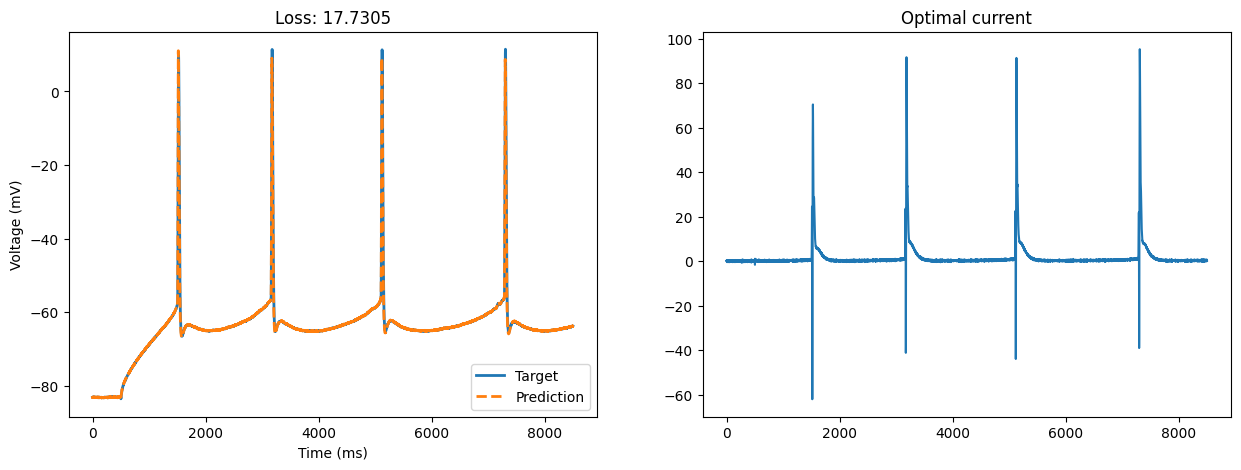

In [14]:
# Change to analytic optimal current

cell = build_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'])
#cell = build_cell(all_setup["swc_fname"], all_setup["rotation"], all_setup['capacitance'], all_setup["eleak"], all_setup['gleak']) # Multi-compartment

cell.delete_stimuli()
cell.delete_recordings()

current = jx.step_current(50, 1000, i_amp, dt, t_max)
current = current[cut:]

cell.stimulate(current)
cell.record()
# cell.soma.branch(0).comp(0).stimulate(current)
# cell.soma.branch(0).comp(0).record()
cell.set("v", all_setup['v_init'])
cell.init_states()

initial_state, step_fn, current, time_vec = setup_simulator_step(cell, cut, t_max, all_setup["v_init"], i_amp, params = inv_sampled_params)

# Run simulation
final_preds, final_ideal_adds, final_i_s = simulate_full_trace(
    initial_state, step_fn, current, time_vec, v_data.squeeze()
)

loss = loss_fn(inv_sampled_params, v_data)

fig, axs = plt.subplots(1,2, figsize = (15,5))
axs[0].plot(v_data[0], label="Data target", linewidth=2)
axs[0].plot(final_preds, label="Single-compartment prediction", linestyle="--", linewidth=2)
axs[0].set_title(f"Loss: {loss:.4f}")
axs[0].set_xlabel("Time (ms)")
axs[0].set_ylabel("Voltage (mV)")
axs[0].legend(["Target", "Prediction"])
axs[1].plot(final_ideal_adds)
axs[1].set_title("Optimal current")

np.save("../results/analytic_pred.npy", final_preds)
np.save("../results/analytic_current.npy", final_ideal_adds)
np.save("../results/analytic_i_s.npy", final_i_s)
np.save("../results/analytic_loss.npy", loss)

Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.


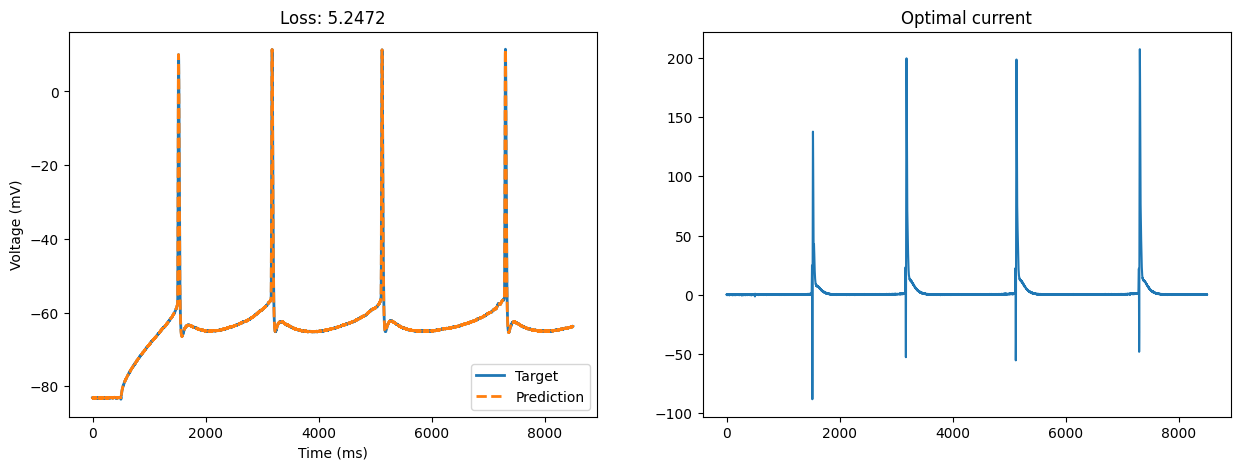

In [16]:
# Change to root search optimal current

cell = build_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'])
#cell = build_cell(all_setup["swc_fname"], all_setup["rotation"], all_setup['capacitance'], all_setup["eleak"], all_setup['gleak']) # Multi-compartment

cell.delete_stimuli()
cell.delete_recordings()

current = jx.step_current(50, 1000, i_amp, dt, t_max)
current = current[cut:]

cell.stimulate(current)
cell.record()
# cell.soma.branch(0).comp(0).stimulate(current)
# cell.soma.branch(0).comp(0).record()
cell.set("v", all_setup['v_init'])
cell.init_states()

initial_state, step_fn, current, time_vec = setup_simulator_step(cell, cut, t_max, all_setup["v_init"], i_amp, params = inv_sampled_params)

# Run simulation
final_preds, final_ideal_adds, final_i_s = simulate_full_trace(
    initial_state, step_fn, current, time_vec, v_data.squeeze()
)

loss = loss_fn(inv_sampled_params, v_data)

fig, axs = plt.subplots(1,2, figsize = (15,5))
axs[0].plot(v_data[0], label="Data target", linewidth=2)
axs[0].plot(final_preds, label="Single-compartment prediction", linestyle="--", linewidth=2)
axs[0].set_title(f"Loss: {loss:.4f}")
axs[0].set_xlabel("Time (ms)")
axs[0].set_ylabel("Voltage (mV)")
axs[0].legend(["Target", "Prediction"])
axs[1].plot(final_ideal_adds)
axs[1].set_title("Optimal current")

np.save("../results/root_search_pred.npy", final_preds)
np.save("../results/root_search_current.npy", final_ideal_adds)
np.save("../results/root_search_i_s.npy", final_i_s)
np.save("../results/root_search_loss.npy", loss)

With a trained single-compartment model (after training produces one spike)

Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.


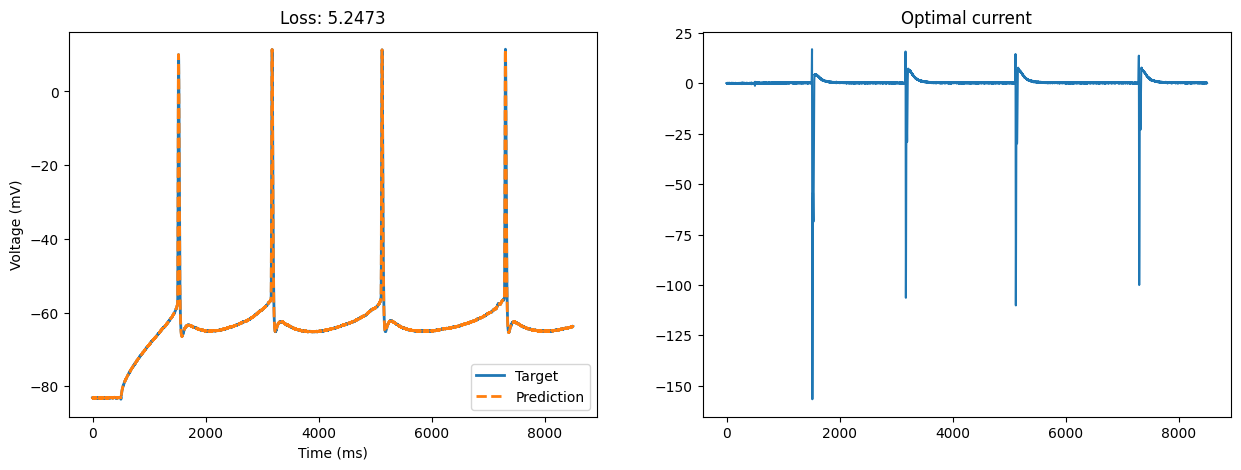

In [18]:
single_best_params = np.load("../results/single_best_params.npy")
cell = build_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'])
#cell = build_cell(all_setup["swc_fname"], all_setup["rotation"], all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'])

cell.delete_stimuli()
cell.delete_recordings()

current = jx.step_current(50, 1000, i_amp, dt, t_max)
current = current[cut:]

cell.stimulate(current)
cell.record()
# cell.soma.branch(0).comp(0).stimulate(current)
# cell.soma.branch(0).comp(0).record()
cell.set("v", all_setup['v_init'])
cell.init_states()

initial_state, step_fn, current, time_vec = setup_simulator_step(cell, cut, t_max, all_setup["v_init"], i_amp, params = single_best_params)

# Run simulation
final_preds, final_ideal_adds, final_i_s = simulate_full_trace(
    initial_state, step_fn, current, time_vec, v_data.squeeze()
)

loss = loss_fn(single_best_params, v_data)

fig, axs = plt.subplots(1,2, figsize = (15,5))
axs[0].plot(v_data[0], label="Data target", linewidth=2)
axs[0].plot(final_preds, label="Single-compartment prediction", linestyle="--", linewidth=2)
axs[0].set_title(f"Loss: {loss:.4f}")
axs[0].set_xlabel("Time (ms)")
axs[0].set_ylabel("Voltage (mV)")
axs[0].legend(["Target", "Prediction"])
axs[1].plot(final_ideal_adds)
axs[1].set_title("Optimal current")

np.save("../results/trained_single_preds.npy", final_preds)
np.save("../results/trained_single_current.npy", final_ideal_adds)
np.save("../results/trained_single_i_s.npy", final_i_s)
np.save("../results/trained_single_loss.npy", loss)

**How much current runs through each channel?**
**In the optimal added current version**

Text(0.5, 1.0, 'Sum')

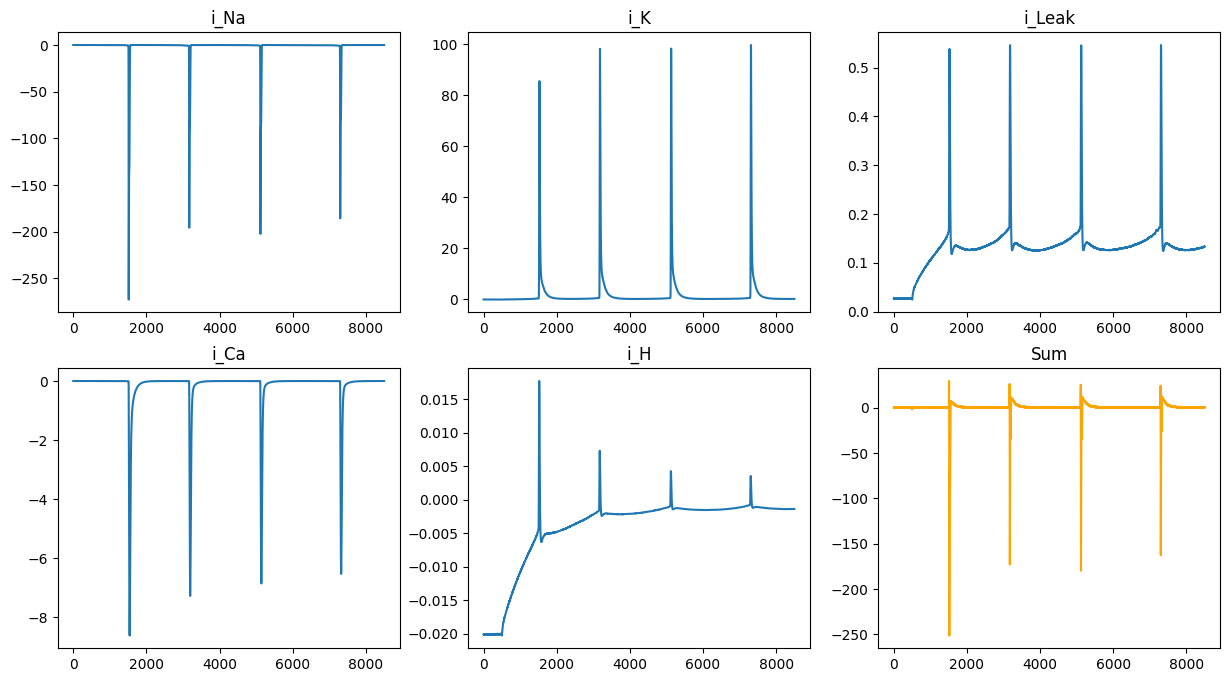

In [19]:
area_cm2 = 2 * jnp.pi * cell.nodes['radius'][0] * cell.nodes['length'][0] * 1e-8

dV = jnp.diff(final_preds) / dt  # in mV/ms
dV = jnp.append(dV, 0.0)  # pad to match length

# Assume cm = 1.0 F/cm² unless otherwise specified
cm = 1.0
I_cap = cm * dV * area_cm2 * 1000

fig, axs = plt.subplots(2,3,figsize=(15,8))
axs[0,0].plot(final_i_s[:,0] * area_cm2 * 1e6)
axs[0,0].set_title('i_Na')
axs[0,1].plot(final_i_s[:,1] * area_cm2 * 1e6)
axs[0,1].set_title('i_K')
axs[0,2].plot(final_i_s[:,2] * area_cm2 * 1e6)
axs[0,2].set_title('i_Leak')
axs[1,0].plot(final_i_s[:,3] * area_cm2 * 1e6)
axs[1,0].set_title('i_Ca')
axs[1,1].plot(final_i_s[:,4] * area_cm2 * 1e6)
axs[1,1].set_title('i_H')
axs[1,2].plot((final_i_s[:,0] + final_i_s[:,1] + final_i_s[:,2] + final_i_s[:,3] + final_i_s[:,4]) * area_cm2 * 1e6 + I_cap, c = 'orange') #+ I_cap
axs[1,2].set_title('Sum')

**Optimal current in the trained MULTI-COMP model**

In [21]:
from voltage_fitting.build_simulator import (
    setup_simulator,
    setup_simulator_step,
    build_cell,
    set_setup,
    get_bounds,
    transform_uniform_to_normal,
    get_prior
)

seed = 0

rng_key = jax.random.PRNGKey(seed)

all_setup = set_setup(setup)
cell = build_cell(all_setup["swc_fname"], all_setup["rotation"], all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'])
simulate = setup_simulator(cell, cut, t_max, all_setup["v_init"], i_amp)


# Sampling parameters
names, lower, upper = get_bounds()


transform_params, inv_transform_params = transform_uniform_to_normal(lower, upper)
sample_prior = get_prior(lower, upper, transform_params)

init_rng_key, sampling_rng_key = jax.random.split(rng_key)

# Sample 1 initialization randomly.
sampled_params = sample_prior(init_rng_key)
inv_sampled_params = inv_transform_params(sampled_params)

v_multi = simulate(inv_sampled_params)

/Users/moldor/Documents/Thesis/jaxley/jaxley/io/swc.py:305: UserWarning: Found a soma which consists of a single traced point. `Jaxley` interprets this soma as a spherical compartment with radius specified in the SWC file, i.e. with surface area 4*pi*r*r.
  warn(


Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.
Number of parameters: 25


Sampled Eigenvalues:
(-42.141613528976286-22.98417698424073j) scaled:  (-1.0535403382244073-0.5746044246060182j)
(-42.141613528976286+22.98417698424073j) scaled:  (-1.0535403382244073+0.5746044246060182j)
(-8.516035334431441+15.86861961008248j) scaled:  (-0.21290088336078605+0.396715490252062j)
(-8.516035334431441-15.86861961008248j) scaled:  (-0.21290088336078605-0.396715490252062j)
(-21.545506252691013-34.14736393037374j) scaled:  (-0.5386376563172753-0.8536840982593437j)
(-21.545506252691013+34.14736393037374j) scaled:  (-0.5386376563172753+0.8536840982593437j)
(-36.88311383073451-19.00424583475928j) scaled:  (-0.9220778457683627-0.47510614586898203j)
(-36.88311383073451+19.00424583475928j) scaled:  (-0.9220778457683627+0.47510614586898203j)


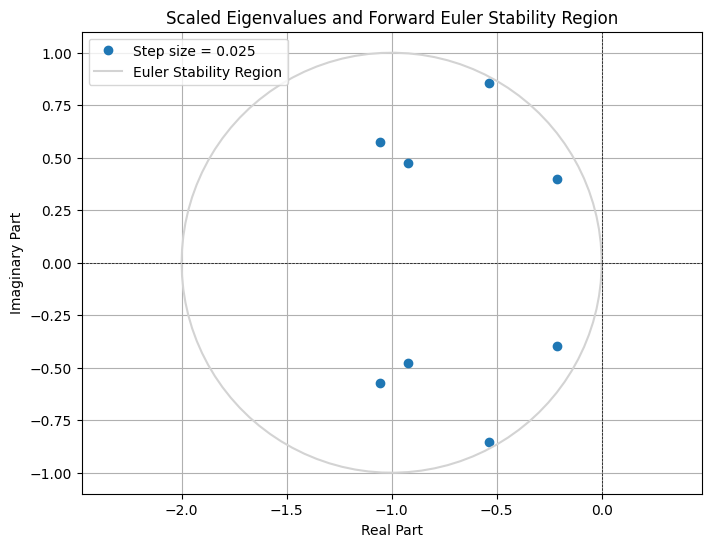

In [22]:
from voltage_fitting.initialization import (
    rejection_sample_eigenvalues,
    generate_all_lambda_matrices,
    generate_all_pi_matrices,
    generate_W_matrices

)
from voltage_fitting.posthoc_summary_stats import (
    find_spikes,
    spike_count,
)

key = jax.random.PRNGKey(0)
dt = 0.025
u_dimension = 8

eigs = rejection_sample_eigenvalues(
    key = key,
    solver_order=1,   # RK4
    h=dt,
    u_dim=u_dimension,
    use_complex=True,
)

print("Sampled Eigenvalues:")
for e in eigs:
    print(e, "scaled: ", dt*e)

# Plotting
fig, ax = plt.subplots(figsize=(8, 6))

# Plot scaled eigenvalues for each h
scaled_eigs = dt*eigs
ax.plot(scaled_eigs.real, scaled_eigs.imag, 'o', label=f"Step size = {dt}")

# Plot Euler's method stability region: circle centered at -1 with radius 1
theta = np.linspace(-np.pi, np.pi, 100)
x = -1 + np.cos(theta)
y = np.sin(theta)
ax.plot(x, y, color='lightgrey', label='Euler Stability Region')

ax.set_xlim(-0.5, 0.5)
ax.set_ylim(-0.2, 0.2)

ax.axhline(0, color='black', linestyle='--', linewidth=0.5)
ax.axvline(0, color='black', linestyle='--', linewidth=0.5)
ax.set_title("Scaled Eigenvalues and Forward Euler Stability Region")
ax.set_xlabel("Real Part")
ax.set_ylabel("Imaginary Part")
ax.legend()
ax.grid(True)
plt.axis('equal')
plt.show()

num_layers = 3
layer_shapes = [(u_dimension + 1, 32), (32, 16), (16, u_dimension)]

lambda_matrices = generate_all_lambda_matrices(layer_shapes, eigs, num_layers)

pi_matrices = generate_all_pi_matrices(key, layer_shapes)

W_matrices = generate_W_matrices(lambda_matrices, pi_matrices)


In [23]:
# Define the neural network
class SimpleNeuralNet(eqx.Module):
    linear1: eqx.nn.Linear
    linear2: eqx.nn.Linear
    linear3: eqx.nn.Linear

    def __init__(self, *, key, u_dimension=8, W_matrices: List[jax.Array], epsilon: float = 1e-4):
        k1, k2, k3, k_b1, k_b2, k_b3 = jr.split(key, 6)

        self.linear1 = eqx.nn.Linear(u_dimension + 1, 32, key=k1)
        self.linear2 = eqx.nn.Linear(32, 16, key=k2)
        self.linear3 = eqx.nn.Linear(16, u_dimension, key=k3)


        self.linear1 = eqx.tree_at(lambda l: l.weight, self.linear1, W_matrices[0])
        self.linear2 = eqx.tree_at(lambda l: l.weight, self.linear2, W_matrices[1])
        self.linear3 = eqx.tree_at(lambda l: l.weight, self.linear3, W_matrices[2])

        self.linear1 = eqx.tree_at(
            lambda l: l.bias, self.linear1,
            jr.uniform(k_b1, (32,), minval=-epsilon, maxval=epsilon)
        )
        self.linear2 = eqx.tree_at(
            lambda l: l.bias, self.linear2,
            jr.uniform(k_b2, (16,), minval=-epsilon, maxval=epsilon)
        )
        self.linear3 = eqx.tree_at(
            lambda l: l.bias, self.linear3,
            jr.uniform(k_b3, (u_dimension,), minval=-epsilon, maxval=epsilon)
        )

    def __call__(self, x):
        x = jax.nn.relu(self.linear1(x))
        x = jax.nn.relu(self.linear2(x))
        return self.linear3(x)


class ReadoutNet(eqx.Module):
    linear1: eqx.nn.Linear
    linear2: eqx.nn.Linear

    def __init__(self, *, key, u_dimension=8):
        k1, k2 = jr.split(key, 2)
        self.linear1 = eqx.nn.Linear(u_dimension, 32, key=k1)
        self.linear2 = eqx.nn.Linear(32, 1, key=k2)

    def __call__(self, u):
        x = jax.nn.relu(self.linear1(u))
        return self.linear2(x)


class CorrectionModel(eqx.Module):
    neural_net: SimpleNeuralNet
    readout_net: ReadoutNet
    channel_params_normal: jax.Array

    def __init__(self, *, key, init_params, u_dimension=8, W_matrices: List[jax.Array], epsilon: float = 1e-4):
        k1, k2 = jr.split(key, 2)
        self.neural_net = SimpleNeuralNet(key=k1, u_dimension=u_dimension, W_matrices=W_matrices, epsilon=epsilon)
        self.readout_net = ReadoutNet(key=k2, u_dimension=u_dimension)
        self.channel_params_normal = init_params

    def __call__(self, u, v):
        u_new = self.neural_net(u, v)
        return self.readout_net(u_new)
    
class DoubleCorrectionModel(eqx.Module):
    spike_neural_net: eqx.Module
    spike_readout_net: eqx.Module
    nospike_neural_net: eqx.Module
    nospike_readout_net: eqx.Module
    channel_params_normal: jnp.ndarray

    def __init__(self, *, key, init_params, u_dimension=8, W_matrices: List[jax.Array], epsilon: float = 1e-4):
        k1, k2, k3, k4 = jr.split(key, 4)
        self.spike_neural_net = SimpleNeuralNet(key=k1, u_dimension=u_dimension, W_matrices=W_matrices, epsilon=epsilon)
        self.spike_readout_net = ReadoutNet(key=k2, u_dimension=u_dimension)
        self.nospike_neural_net = SimpleNeuralNet(key=k3, u_dimension=u_dimension, W_matrices=W_matrices, epsilon=epsilon)
        self.nospike_readout_net = ReadoutNet(key=k4, u_dimension=u_dimension)
        self.channel_params_normal = init_params

    def __call__(self, u, v):
        u_new = self.neural_net(u, v)
        return self.readout_net(u_new)

In [24]:
dt = 0.025
dv_treshold = 0.5


def simulate_full_trace(spike_neural_net, spike_readout_net, nospike_neural_net, nospike_readout_net, initial_state, step_fn, current, time_vec, u_init, x_o, added_curr_std, nospike_u_time_constant, spike_u_time_constant, thr = None):
    def cond_fn(carry):
        t, _, _, _, _, diff, _ = carry
        keep_running = t < len(time_vec)
    
        if thr is None:
            return keep_running
        else:
            return jnp.logical_and(keep_running, diff < thr)

    def body_fn(carry):
        t, state, u, recs_adds, i_s, diff, prev_voltage = carry

        voltage = state["v"][0].squeeze()
        voltage_normalized = normalize_voltage(voltage)
        #voltage_normalized = softsign_transform(voltage)
        #voltage_normalized = tempered_tanh(voltage)


        inputs = jnp.concatenate([u, jnp.expand_dims(voltage_normalized, 0)], axis=0)

        # Spike/Nospike?
        dv = jnp.abs(voltage - prev_voltage)
        use_spike_net = dv > dv_treshold #jnp.logical_or(dv > dv_treshold), voltage > -40.0)
        
        # Compute add_current using spike/nospike NNs
        neural_net_output = jax.lax.cond(use_spike_net, lambda: spike_neural_net(inputs), lambda: nospike_neural_net(inputs))
        u_time_constant = jax.lax.cond(use_spike_net, lambda: spike_u_time_constant, lambda: nospike_u_time_constant)
        u_new = u + dt*neural_net_output / u_time_constant

        readout_net_output = jax.lax.cond(use_spike_net, lambda: spike_readout_net(u_new), lambda: nospike_readout_net(u_new))
        add_current = readout_net_output.squeeze()
        



        total_current = current[t] + add_current * added_curr_std
        state, rec = step_fn(state, total_current)
        rec_voltage = rec[0]

        i_Na = state["i_Na"][0]
        i_K = state["i_K"][0]
        i_Leak = state["i_Leak"][0]
        i_Ca = state["i_Ca"][0]
        i_H = state["i_H"][0]


        i_s = i_s.at[t].set(jnp.asarray([i_Na, i_K, i_Leak, i_Ca, i_H]))
        new_us, new_recs, new_adds, nn_reses = recs_adds
        new_recs = new_recs.at[t].set(rec_voltage)
        new_adds = new_adds.at[t].set(add_current)
        new_us = new_us.at[t].set(u_new)
        nn_reses = nn_reses.at[t].set(neural_net_output)

        new_diff = diff + (rec_voltage - x_o[t + 1])**2

        return (t + 1, state, u_new.squeeze(), (new_us, new_recs, new_adds, nn_reses), i_s, new_diff, voltage)


    # Initialize buffers
    recs = jnp.full((len(time_vec),), jnp.nan)
    adds = jnp.full((len(time_vec),), jnp.nan)
    i_s = jnp.full((len(time_vec),5), jnp.nan)
    us = jnp.full((len(time_vec), u_init.shape[0]), jnp.nan)
    nn_reses = jnp.full((len(time_vec), u_init.shape[0]), jnp.nan)

    carry = (0, initial_state, u_init.squeeze(), (us, recs, adds, nn_reses), i_s, 0.0, initial_state["v"][0].squeeze())

    final_carry = eqx.internal.while_loop(
        cond_fun=cond_fn,
        body_fun=body_fn,
        init_val=carry,
        max_steps=len(time_vec),
        kind="bounded"
    )

    _, _, _, (us, recs, adds, nn_reses), i_s, _, _ = final_carry

    return recs, adds, us, nn_reses, i_s

In [25]:
cost_fn_power = 1.0
scale = 0.05 #0.05

from voltage_fitting.loss_util import (
    get_scaled_loss
)


def loss_fn(model, all_setup, t_max, i_amp, u_init, v_data, added_curr_std, nospike_u_time_constant, spike_u_time_constant, thr=300, dtw_reg = 1.0, spike_reg = 0.0, sse_reg = 0.0, add_reg = 0.0):

    params = inv_transform_params(model.channel_params_normal)

    # Rebuild the simulator with new cell
    initial_state, step_fn, current, time_vec = setup_simulator_step(cell, cut, t_max, all_setup["v_init"], i_amp, params = params)

    # Run simulation
    preds, additional_currents, _, _, _ = simulate_full_trace(
        model.spike_neural_net, model.spike_readout_net, model.nospike_neural_net, model.nospike_readout_net, initial_state, step_fn, current, time_vec, u_init, v_data.squeeze(), added_curr_std, nospike_u_time_constant, spike_u_time_constant, thr
    )

    preds = preds.squeeze()
    v_data = v_data.squeeze()

    sse_loss = jnp.sum(jnp.nan_to_num((preds - v_data) ** 2, nan=0.0))
    add_loss = jnp.sum(jnp.abs(jnp.nan_to_num(additional_currents, nan=0.0)))
    dtw_loss = get_scaled_loss(v_data, preds, cost_fn_power, scale)

    noise = np.random.randn(len(preds)) * 1e-2
    preds_spikes = find_spikes(preds + noise, None, None, thr = -20.0)

    noise = np.random.randn(len(v_data)) * 1e-2
    v_data_spikes = find_spikes(v_data + noise, None, None, thr = -20.0)


    spike_loss = jnp.abs(spike_count(preds_spikes) - spike_count(v_data_spikes)) ** 2
    
    return dtw_loss * dtw_reg + sse_loss * sse_reg + spike_loss * spike_reg + add_loss * add_reg

In [26]:
u_dimension = 8
np.random.seed(42)
n_particles = 200

key1 = jax.random.PRNGKey(0)
key2 = jax.random.PRNGKey(1)
keys = jax.random.split(jax.random.PRNGKey(0), num=n_particles)

u_init = jnp.asarray(np.random.randn(u_dimension))  # Initial hidden state of the neural network
epsilon = 1e-4

all_setup = set_setup(setup)

# Different, random u_time_constant vectors for spike/nospike regions
log_uniform_samples = jax.random.uniform(key1, shape=(u_dimension,), minval=np.log(1), maxval=np.log(100.0))
nospike_u_time_constant = jnp.exp(log_uniform_samples)

log_uniform_samples = jax.random.uniform(key2, shape=(u_dimension,), minval=np.log(0.1), maxval=np.log(10.0))
spike_u_time_constant = jnp.exp(log_uniform_samples)

added_curr_std = 1.0/100.0


thr = None


initial_lr = 15e-4 #2e-1 for lbfgs?
decay_factor = 0.99
transition_steps = 1  # decay after every epoch
#decay_until = 400 # after x epochs, stop decaying
decay_start = 1
decay_end = 350


opt_params = jax.vmap(sample_prior)(
    jax.random.split(init_rng_key, n_particles)
)


def initialize_model(key, init_params, u_dimension, W_matrices, epsilon):
    model = DoubleCorrectionModel(
        key=key,
        init_params=init_params,
        u_dimension=u_dimension,
        W_matrices=W_matrices,
        epsilon=epsilon
    )
    return model



models_for_shape = jax.vmap(initialize_model, in_axes=(0, 0, None, None, None))(
    keys, opt_params, u_dimension, W_matrices, epsilon
)

def simulation_loss_fn(all_params):
        loss = loss_fn(all_params, all_setup, t_max, i_amp, u_init, v_data, added_curr_std, nospike_u_time_constant, spike_u_time_constant, thr, dtw_reg = 1.0, spike_reg = 0.0, sse_reg = 0.0, add_reg = 0.0)
        return loss

with open("../results/best_trained_models.eqx", "rb") as f:
    models = eqx.tree_deserialise_leaves(f, models_for_shape)


/Users/moldor/Documents/Thesis/jaxley/jaxley/io/swc.py:305: UserWarning: Found a soma which consists of a single traced point. `Jaxley` interprets this soma as a spherical compartment with radius specified in the SWC file, i.e. with surface area 4*pi*r*r.
  warn(


Text(0.5, 1.0, 'Final total current')

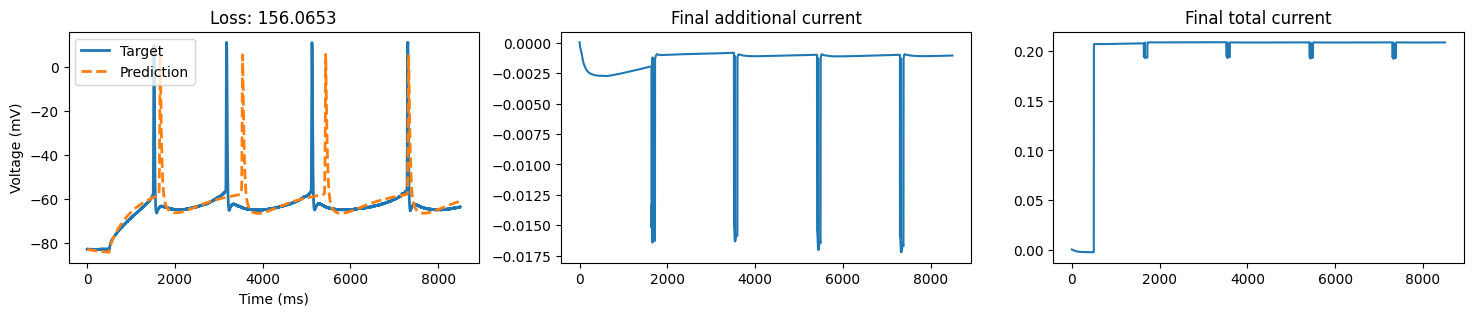

In [29]:
model = jax.tree_util.tree_map(lambda x: x[87], models)
opt_inv_params = inv_transform_params(model.channel_params_normal)

# Rebuild the simulator with new cell
cell = build_cell(all_setup["swc_fname"], all_setup["rotation"], all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'])

cell.delete_stimuli()
cell.delete_recordings()

current = jx.step_current(50, 1000, i_amp, dt, t_max)
current = current[cut:]

cell.soma.branch(0).comp(0).stimulate(current, verbose = False)
cell.soma.branch(0).comp(0).record(verbose = False)
cell.set("v", all_setup['v_init'])
cell.init_states()

initial_state, step_fn, current, time_vec = setup_simulator_step(cell, cut, t_max, all_setup["v_init"], i_amp, params = opt_inv_params)

# Run simulation
final_preds, final_additional_currents, final_us, final_nn_reses, final_i_s = simulate_full_trace(
model.spike_neural_net, model.spike_readout_net, model.nospike_neural_net, model.nospike_readout_net, initial_state, step_fn, current, time_vec, u_init, v_data.squeeze(), added_curr_std, nospike_u_time_constant, spike_u_time_constant, thr
)

loss = simulation_loss_fn(model)

fig, axs = plt.subplots(1,3, figsize = (18,3))
axs[0].plot(v_data[0], label="Data target", linewidth=2)
axs[0].plot(final_preds, label="Single-compartment prediction", linestyle="--", linewidth=2)
axs[0].set_title(f"Loss: {loss:.4f}")
axs[0].set_xlabel("Time (ms)")
axs[0].set_ylabel("Voltage (mV)")
axs[0].legend(["Target", "Prediction"])
axs[1].plot(final_additional_currents* added_curr_std)
axs[1].set_title("Final additional current")
axs[2].plot(current + final_additional_currents[:-1] * added_curr_std)
axs[2].set_title("Final total current")

/Users/moldor/Documents/Thesis/jaxley/jaxley/io/swc.py:305: UserWarning: Found a soma which consists of a single traced point. `Jaxley` interprets this soma as a spherical compartment with radius specified in the SWC file, i.e. with surface area 4*pi*r*r.
  warn(


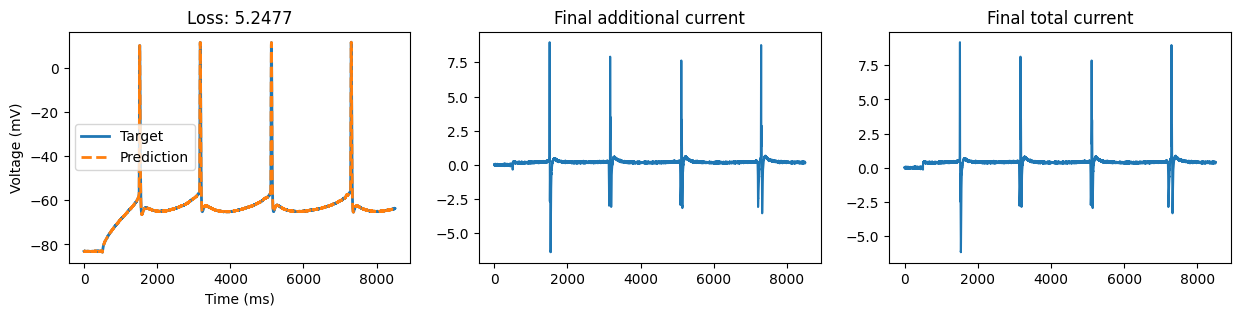

In [36]:
model = jax.tree_util.tree_map(lambda x: x[87], models)
opt_inv_params = inv_transform_params(model.channel_params_normal)

# Rebuild the simulator with new cell
cell = build_cell(all_setup["swc_fname"], all_setup["rotation"], all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'])

cell.delete_stimuli()
cell.delete_recordings()

current = jx.step_current(50, 1000, i_amp, dt, t_max)
current = current[cut:]

cell.soma.branch(0).comp(0).stimulate(current, verbose = False)
cell.soma.branch(0).comp(0).record(verbose = False)
cell.set("v", all_setup['v_init'])
cell.init_states()

initial_state, step_fn, current, time_vec = setup_simulator_step(cell, cut, t_max, all_setup["v_init"], i_amp, params = opt_inv_params)

# Run simulation
# final_preds, final_additional_currents, final_us, final_nn_reses, final_i_s = simulate_full_trace(
# model.spike_neural_net, model.spike_readout_net, model.nospike_neural_net, model.nospike_readout_net, initial_state, step_fn, current, time_vec, u_init, v_data.squeeze(), added_curr_std, nospike_u_time_constant, spike_u_time_constant, thr
# )

# Run the simulate_full_trace that computes the optimal current and the loss!
final_preds, final_ideal_adds, final_i_s = simulate_full_trace(
    initial_state, step_fn, current, time_vec, v_data.squeeze()
)

loss = loss_fn(opt_inv_params, v_data)

fig, axs = plt.subplots(1, 3, figsize = (15,3))
axs[0].plot(v_data[0], label="Data target", linewidth=2)
axs[0].plot(final_preds, label="Single-compartment prediction", linestyle="--", linewidth=2)
axs[0].set_title(f"Loss: {loss:.4f}")
axs[0].set_xlabel("Time (ms)")
axs[0].set_ylabel("Voltage (mV)")
axs[0].legend(["Target", "Prediction"])
axs[1].plot(final_ideal_adds)
axs[1].set_title("Final additional current")
axs[2].plot(current + final_ideal_adds[:-1])
axs[2].set_title("Final total current")

np.save("../results/trained_pred.npy", final_preds)
np.save("../results/trained_current.npy", final_ideal_adds)
np.save("../results/trained_i_s.npy", final_i_s)
np.save("../results/trained_loss.npy", loss)


In [37]:
def compute_area_cm2(cell):
    s = 0
    for i in range(412):
        s += 2 * jnp.pi * cell.nodes['radius'][i] * cell.nodes['length'][i] * 1e-8
    return s

def compute_area_cm2_Na_K(cell):
    s = 0
    for i in range(412):
        if(cell.nodes.soma[i] == True or cell.nodes.axon[i] == True or cell.nodes.apical[i] == True):
            s += 2 * jnp.pi * cell.nodes['radius'][i] * cell.nodes['length'][i] * 1e-8
    return s


def compute_area_cm2_Ca(cell):
    s = 0
    for i in range(412):
        if(cell.nodes.soma[i] == True or cell.nodes.axon[i] == True):
            s += 2 * jnp.pi * cell.nodes['radius'][i] * cell.nodes['length'][i] * 1e-8
    return s

def compute_area_cm2_H(cell):
    s = 0
    for i in range(412):
        if(cell.nodes.apical[i] == True or cell.nodes.basal[i] == True):
            s += 2 * jnp.pi * cell.nodes['radius'][i] * cell.nodes['length'][i] * 1e-8
    return s

def compute_area_cm2_soma(cell):
    s = 0
    for i in range(412):
        if(cell.nodes.soma[i] == True):
            s += 2 * jnp.pi * cell.nodes['radius'][i] * cell.nodes['length'][i] * 1e-8
    return s

Text(0.5, 1.0, 'Sum')

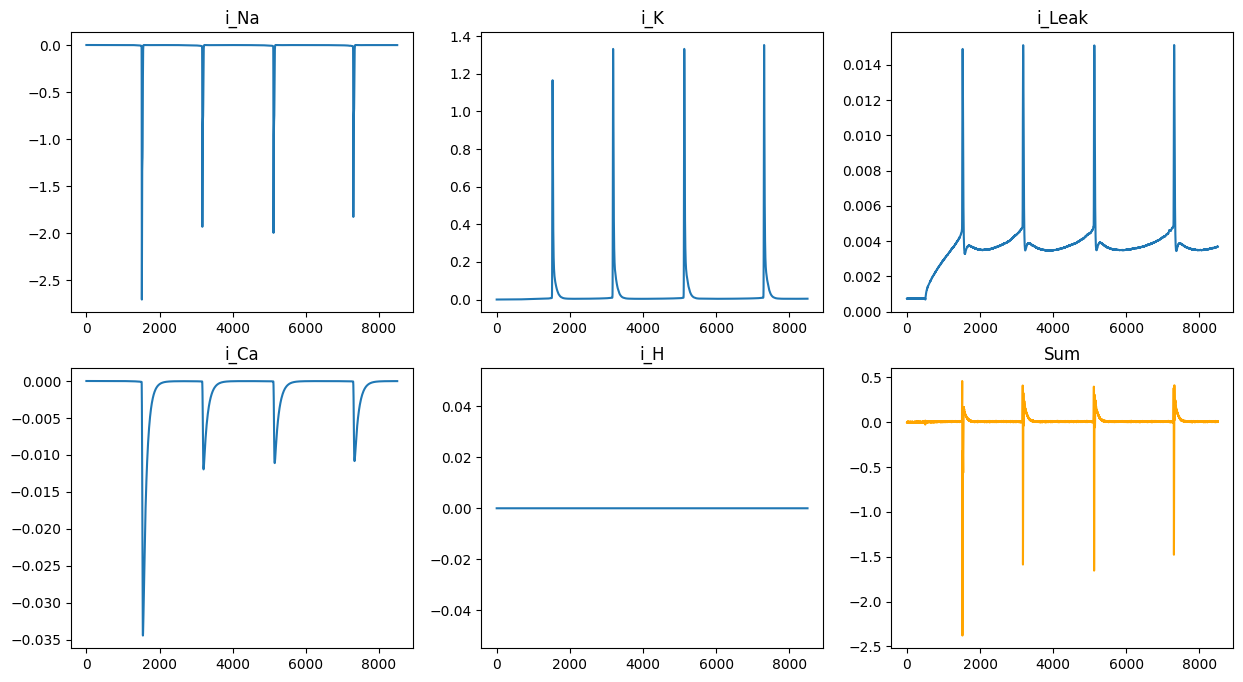

In [ ]:
area_cm2_Na_K = compute_area_cm2_Na_K(cell)
area_cm2 = compute_area_cm2(cell)
area_cm2_Ca = compute_area_cm2_Ca(cell)
area_cm2_H = compute_area_cm2_H(cell)
area_cm2_soma = compute_area_cm2_soma(cell)

dV = jnp.diff(final_preds) / dt  # in mV/ms
dV = jnp.append(dV, 0.0)  # pad to match length


cm = 1.0
I_cap = cm * dV * area_cm2_soma/4.0 * 1e3

fig, axs = plt.subplots(2,3,figsize=(15,8))
axs[0,0].plot(final_i_s[:,0] * area_cm2_soma/4.0 * 1e6)
axs[0,0].set_title('i_Na')
axs[0,1].plot(final_i_s[:,1] * area_cm2_soma/4.0 * 1e6)
axs[0,1].set_title('i_K')
axs[0,2].plot(final_i_s[:,2] * area_cm2_soma/4.0 * 1e6)
axs[0,2].set_title('i_Leak')
axs[1,0].plot(final_i_s[:,3] * area_cm2_soma/4.0 * 1e6)
axs[1,0].set_title('i_Ca')
axs[1,1].plot(final_i_s[:,4] * area_cm2_soma/4.0 * 1e6)
axs[1,1].set_title('i_H')
axs[1,2].plot((final_i_s[:,0] + final_i_s[:,1] + final_i_s[:,2] + final_i_s[:,3] + final_i_s[:,4]) * area_cm2_soma/4.0 * 1e6 + I_cap, c = 'orange')
axs[1,2].set_title('Sum')

**Let's learn the ideal input current with the NN - doesn't work, as hard as the true voltage**